<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/01_convolutional_neural_networks_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN)

Convolutional Neural Networks (CNNs) are a type of deep learning model specifically designed for image data.

Unlike traditional neural networks, CNNs automatically learn important features such as edges, textures, and shapes directly from images.

CNNs use convolution and pooling operations to reduce the number of parameters while preserving important visual information.

They are widely used in image classification, object detection, face recognition, and medical image analysis.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

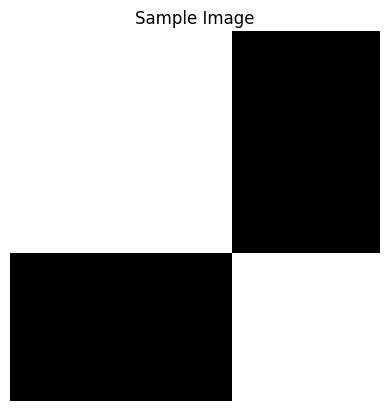

In [2]:
image = np.array([
    [1,1,1,0,0],
    [1,1,1,0,0],
    [1,1,1,0,0],
    [0,0,0,1,1],
    [0,0,0,1,1]
])

plt.imshow(image, cmap="gray")
plt.title("Sample Image")
plt.axis("off")
plt.show()

In [3]:
kernel = np.array([
    [1,0],
    [0,-1]
])

print(kernel)

[[ 1  0]
 [ 0 -1]]


In [4]:
output = np.zeros((4,4))

for i in range(4):
    for j in range(4):
        region = image[i:i+2, j:j+2]
        output[i, j] = np.sum(region * kernel)

print(output)

[[ 0.  0.  1.  0.]
 [ 0.  0.  1.  0.]
 [ 1.  1.  0. -1.]
 [ 0.  0. -1.  0.]]


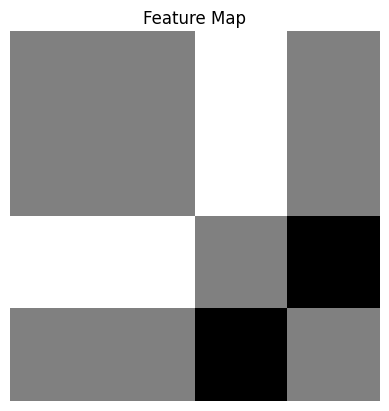

In [5]:
plt.imshow(output, cmap="gray")
plt.title("Feature Map")
plt.axis("off")
plt.show()

In [6]:
feature_map = np.array([
    [1,3,2,1],
    [4,6,5,2],
    [2,8,7,3],
    [1,2,4,5]
])

pooled = np.zeros((2,2))

for i in range(0,4,2):
    for j in range(0,4,2):
        pooled[i//2, j//2] = np.max(feature_map[i:i+2, j:j+2])

print(pooled)

[[6. 5.]
 [8. 7.]]


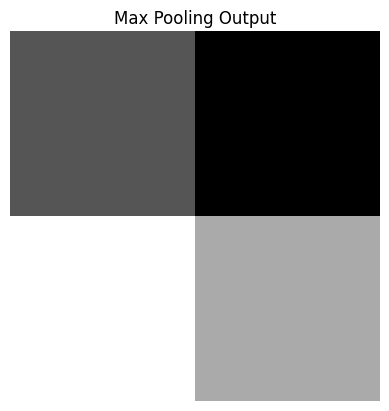

In [7]:
plt.imshow(pooled, cmap="gray")
plt.title("Max Pooling Output")
plt.axis("off")
plt.show()

In [8]:
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import pandas as pd

comparison = pd.DataFrame({

    "ANN":[
        "Works well for tabular data",
        "Large number of parameters",
        "Does not preserve spatial information"
    ],

    "CNN":[
        "Designed for image data",
        "Fewer parameters using filters",
        "Preserves spatial relationships"
    ]

})

comparison

,ANN,CNN
0,Works well for tabular data,Designed for image data
1,Large number of parameters,Fewer parameters using filters
2,Does not preserve spatial information,Preserves spatial relationships


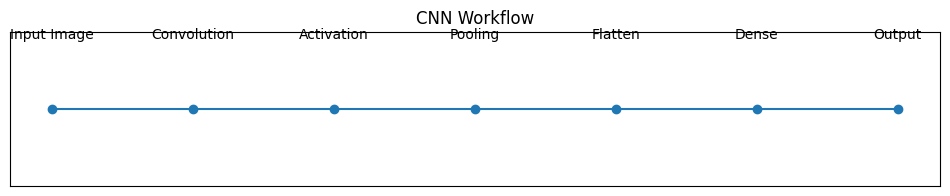

In [10]:
steps = [
    "Input Image",
    "Convolution",
    "Activation",
    "Pooling",
    "Flatten",
    "Dense",
    "Output"
]

plt.figure(figsize=(12,2))
plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])
plt.title("CNN Workflow")

plt.show()